# Home Credit Default Risk — Exploratory Data Analysis

Exploratory analysis of the Home Credit Default Risk dataset (Kaggle),
focused on the main application_train.csv table. The goal is to understand
the data before feature engineering and modeling: assess data quality,
understand the target variable, and identify which features show a
meaningful relationship with credit default risk.

## Key Findings

- **Dataset**: 307,511 loan applications, 122 columns (application_train.csv only — 6 additional linked tables exist and will be explored during feature engineering).
- **Class imbalance**: 91.9% repaid vs. 8.1% with payment difficulties (~11:1) — accuracy would be misleading; the competition uses AUC-ROC instead.
- **Missing values**: 67 of 122 columns have missing values. The 41 columns with the highest missingness (50-70%) are almost all building/apartment characteristics, appearing to stem from an optional data source rather than random gaps.
- **A recurring "not currently employed" signal**: DAYS_EMPLOYED (placeholder value 365243), OCCUPATION_TYPE (missing), and ORGANIZATION_TYPE ("XNA") all flag the exact same 55,374 applicants (mostly pensioners) — three independent columns encoding the same underlying group.
- **Data quality issues confirmed and explained**: an implausible AMT_INCOME_TOTAL value (117M) traced to a likely data entry error; a rare CODE_GENDER placeholder ("XNA", 4 rows); currency/units for monetary columns are undocumented and likely not EUR/USD.
- **Consistent risk pattern across independent features**: younger age, lower education, renting/living with parents, and lower-skilled occupations (e.g. Low-skill Laborers, Construction) are all independently associated with higher default rates — several unrelated signals pointing the same direction.
- **EXT_SOURCE_1/2/3 are by far the strongest predictors**: normalized external scores with correlations 3x stronger than any other feature. Default rate drops from 18.3% (lowest decile) to 3.0% (highest decile) for EXT_SOURCE_2 alone.
- **Modeling direction**: given the missing data, class imbalance, and outliers/skew found throughout, gradient-boosted trees (LightGBM/XGBoost) are a strong candidate — they handle missing values natively, support class weighting, and don't require scaling. We'll validate this against a simple baseline (Logistic Regression) rather than assume it.

Let's first import the libraries and set parameters for a consistent plot style.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 200)

plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['figure.figsize'] = (7, 4)

We'll also load the column description file alongside the main data — it
translates cryptic column names into plain-language explanations, which
we'll come back to throughout this notebook whenever a feature needs
clarification.

In [2]:
description = pd.read_csv(
    '/kaggle/input/competitions/home-credit-default-risk/HomeCredit_columns_description.csv',
    encoding='latin-1'
)
description[description['Row'] == 'TARGET']

,Unnamed: 0,Table,Row,Description,Special
1,2,application_{train|test}.csv,TARGET,Target variable (1 - client with payment diffi...,NaN


Let's have a first look at the training data set.

In [3]:
app_train = pd.read_csv('/kaggle/input/competitions/home-credit-default-risk/application_train.csv')

print('Shape:', app_train.shape)

Shape: (307511, 122)


Let's check the data types of all columns to understand what we're working
with — numerical vs. categorical — before looking at the actual data.

In [4]:
app_train.dtypes.value_counts()

float64    65
int64      41
object     16
Name: count, dtype: int64

## Data Overview

The training dataset contains 307,511 loan applications with 122 columns:
65 numerical (float), 41 integer, and 16 categorical (object) features.
The object columns are text/categories and will need to be encoded later for modeling.

Let's look at the first few rows to get a concrete sense of what information
is actually captured — applicant demographics, income, loan terms, and more.

In [5]:
app_train.head()

,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,AMT_GOODS_PRICE,NAME_TYPE_SUITE,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,REGION_POPULATION_RELATIVE,DAYS_BIRTH,DAYS_EMPLOYED,DAYS_REGISTRATION,DAYS_ID_PUBLISH,OWN_CAR_AGE,FLAG_MOBIL,FLAG_EMP_PHONE,FLAG_WORK_PHONE,FLAG_CONT_MOBILE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,REGION_RATING_CLIENT,REGION_RATING_CLIENT_W_CITY,WEEKDAY_APPR_PROCESS_START,HOUR_APPR_PROCESS_START,REG_REGION_NOT_LIVE_REGION,REG_REGION_NOT_WORK_REGION,LIVE_REGION_NOT_WORK_REGION,REG_CITY_NOT_LIVE_CITY,REG_CITY_NOT_WORK_CITY,LIVE_CITY_NOT_WORK_CITY,ORGANIZATION_TYPE,EXT_SOURCE_1,EXT_SOURCE_2,EXT_SOURCE_3,APARTMENTS_AVG,BASEMENTAREA_AVG,YEARS_BEGINEXPLUATATION_AVG,YEARS_BUILD_AVG,COMMONAREA_AVG,ELEVATORS_AVG,ENTRANCES_AVG,FLOORSMAX_AVG,FLOORSMIN_AVG,LANDAREA_AVG,LIVINGAPARTMENTS_AVG,LIVINGAREA_AVG,NONLIVINGAPARTMENTS_AVG,NONLIVINGAREA_AVG,APARTMENTS_MODE,BASEMENTAREA_MODE,YEARS_BEGINEXPLUATATION_MODE,YEARS_BUILD_MODE,COMMONAREA_MODE,ELEVATORS_MODE,ENTRANCES_MODE,FLOORSMAX_MODE,FLOORSMIN_MODE,LANDAREA_MODE,LIVINGAPARTMENTS_MODE,LIVINGAREA_MODE,NONLIVINGAPARTMENTS_MODE,NONLIVINGAREA_MODE,APARTMENTS_MEDI,BASEMENTAREA_MEDI,YEARS_BEGINEXPLUATATION_MEDI,YEARS_BUILD_MEDI,COMMONAREA_MEDI,ELEVATORS_MEDI,ENTRANCES_MEDI,FLOORSMAX_MEDI,FLOORSMIN_MEDI,LANDAREA_MEDI,LIVINGAPARTMENTS_MEDI,LIVINGAREA_MEDI,NONLIVINGAPARTMENTS_MEDI,NONLIVINGAREA_MEDI,FONDKAPREMONT_MODE,HOUSETYPE_MODE,TOTALAREA_MODE,WALLSMATERIAL_MODE,EMERGENCYSTATE_MODE,OBS_30_CNT_SOCIAL_CIRCLE,DEF_30_CNT_SOCIAL_CIRCLE,OBS_60_CNT_SOCIAL_CIRCLE,DEF_60_CNT_SOCIAL_CIRCLE,DAYS_LAST_PHONE_CHANGE,FLAG_DOCUMENT_2,FLAG_DOCUMENT_3,FLAG_DOCUMENT_4,FLAG_DOCUMENT_5,FLAG_DOCUMENT_6,FLAG_DOCUMENT_7,FLAG_DOCUMENT_8,FLAG_DOCUMENT_9,FLAG_DOCUMENT_10,FLAG_DOCUMENT_11,FLAG_DOCUMENT_12,FLAG_DOCUMENT_13,FLAG_DOCUMENT_14,FLAG_DOCUMENT_15,FLAG_DOCUMENT_16,FLAG_DOCUMENT_17,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,351000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.018801,-9461,-637,-3648.0,-2120,NaN,1,1,0,1,1,0,Laborers,1.0,2,2,WEDNESDAY,10,0,0,0,0,0,0,Business Entity Type 3,0.083037,0.262949,0.139376,0.0247,0.0369,0.9722,0.6192,0.0143,0.00,0.0690,0.0833,0.1250,0.0369,0.0202,0.0190,0.0000,0.0000,0.0252,0.0383,0.9722,0.6341,0.0144,0.0000,0.0690,0.0833,0.1250,0.0377,0.022,0.0198,0.0,0.0,0.0250,0.0369,0.9722,0.6243,0.0144,0.00,0.0690,0.0833,0.1250,0.0375,0.0205,0.0193,0.0000,0.00,reg oper account,block of flats,0.0149,"Stone, brick",No,2.0,2.0,2.0,2.0,-1134.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,1129500.0,Family,State servant,Higher education,Married,House / apartment,0.003541,-16765,-1188,-1186.0,-291,NaN,1,1,0,1,1,0,Core staff,2.0,1,1,MONDAY,11,0,0,0,0,0,0,School,0.311267,0.622246,NaN,0.0959,0.0529,0.9851,0.7960,0.0605,0.08,0.0345,0.2917,0.3333,0.0130,0.0773,0.0549,0.0039,0.0098,0.0924,0.0538,0.9851,0.8040,0.0497,0.0806,0.0345,0.2917,0.3333,0.0128,0.079,0.0554,0.0,0.0,0.0968,0.0529,0.9851,0.7987,0.0608,0.08,0.0345,0.2917,0.3333,0.0132,0.0787,0.0558,0.0039,0.01,reg oper account,block of flats,0.0714,Block,No,1.0,0.0,1.0,0.0,-828.0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,135000.0,Unaccompanied,Working,Secondary / secondary special,Single / not married,House / apartment,0.010032,-19046,-225,-4260.0,-2531,26.0,1,1,1,1,1,0,Laborers,1.0,2,2,MONDAY,9,0,0,0,0,0,0,Government,NaN,0.555912,0.729567,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

The columns cover applicant demographics (gender, family status, education),
financial details (income, credit amount, annuity), and housing/employment
information — consistent with the feature categories we'll explore in more
depth throughout this notebook.

## Target Variable Distribution

Let's check the class balance of TARGET (1 = payment difficulties, 0 = repaid on time).

In [6]:
app_train['TARGET'].value_counts()

TARGET
0    282686
1     24825
Name: count, dtype: int64

Only 8.1% of loans in the training set have TARGET=1 (payment difficulties),
compared to 91.9% with TARGET=0. This is a highly imbalanced dataset (~11:1 ratio),
which matters for model evaluation later — accuracy would be misleading here,
so the competition uses AUC-ROC instead. We'll likely need class weighting or
resampling when we get to modeling.

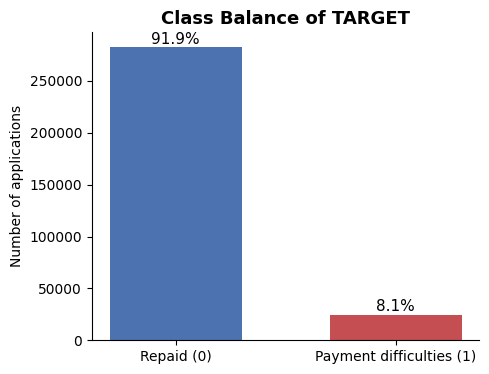

In [7]:
counts = app_train['TARGET'].value_counts().sort_index()
percentages = counts / counts.sum() * 100

colors = ['#4C72B0', '#C44E52']  # neutral blue = repaid, red = payment difficulties

fig, ax = plt.subplots(figsize=(5, 4))
bars = ax.bar(['Repaid (0)', 'Payment difficulties (1)'], counts, color=colors, width=0.6)

for bar, pct in zip(bars, percentages):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3000,
            f'{pct:.1f}%', ha='center', fontsize=11)

ax.set_title('Class Balance of TARGET', fontsize=13, weight='bold')
ax.set_ylabel('Number of applications')
ax.spines[['top', 'right']].set_visible(False)
plt.show()

## Missing Values

Let's check which columns have missing values and how severe it is.

In [8]:
missing = app_train.isnull().sum()
missing_pct = (missing / len(app_train) * 100).round(2)

missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})
missing_df = missing_df[missing_df['missing_count'] > 0].sort_values('missing_pct', ascending=False)

print(f'Columns with missing values: {len(missing_df)} out of {app_train.shape[1]}')
missing_df.head(15)

Columns with missing values: 67 out of 122


,missing_count,missing_pct
COMMONAREA_MEDI,214865,69.87
COMMONAREA_MODE,214865,69.87
COMMONAREA_AVG,214865,69.87
NONLIVINGAPARTMENTS_MODE,213514,69.43
NONLIVINGAPARTMENTS_MEDI,213514,69.43
NONLIVINGAPARTMENTS_AVG,213514,69.43
FONDKAPREMONT_MODE,210295,68.39
LIVINGAPARTMENTS_AVG,210199,68.35
LIVINGAPARTMENTS_MEDI,210199,68.35
LIVINGAPARTMENTS_MODE,210199,68.35


67 out of 122 columns contain missing values. The columns with the highest
missing rates (65-70%) are almost all building/apartment characteristics
(e.g. COMMONAREA, LIVINGAPARTMENTS, FLOORSMIN), each appearing in three
variants: _AVG, _MODE, _MEDI. This suggests these come from an optional data
source not available for most applicants, rather than random missingness.
We'll decide how to handle these (drop, flag, or keep for tree-based models)
during feature engineering.

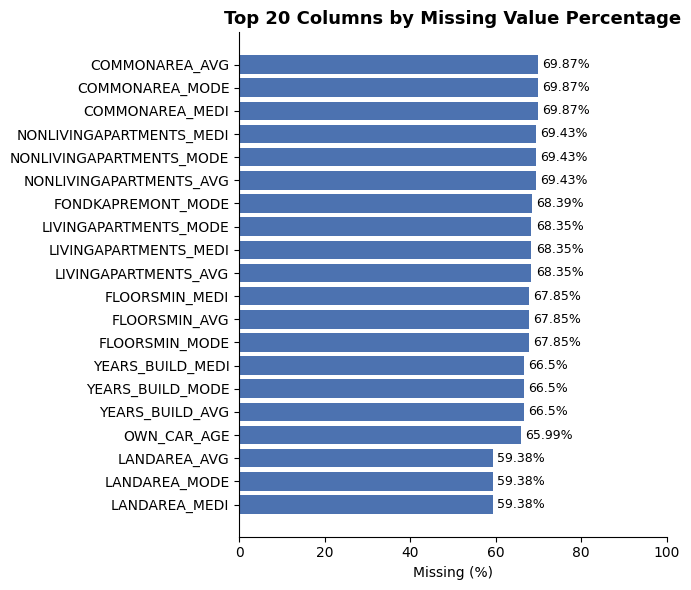

In [9]:
top20 = missing_df.head(20).sort_values('missing_pct')

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(top20.index, top20['missing_pct'], color='#4C72B0')

for i, pct in enumerate(top20['missing_pct']):
    ax.text(pct + 1, i, f'{pct}%', va='center', fontsize=9)

ax.set_xlabel('Missing (%)')
ax.set_title('Top 20 Columns by Missing Value Percentage', fontsize=13, weight='bold')
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(0, 100)
plt.tight_layout()
plt.show()

In [10]:
bins = [0, 20, 50, 70, 100]
labels = ['0-20%', '20-50%', '50-70%', '70-100%']
missing_df['bucket'] = pd.cut(missing_df['missing_pct'], bins=bins, labels=labels)

missing_df['bucket'].value_counts().sort_index()

bucket
0-20%      14
20-50%      9
50-70%     41
70-100%     0
Name: count, dtype: int64

## Missing Values Summary

41 of 122 columns have high missingness (50-70%), mostly the building/apartment
features identified above. We'll decide the exact handling strategy during
feature engineering.

Looking ahead to modeling: given the volume of missing data and the class
imbalance we found earlier (91.9% vs. 8.1%), gradient-boosted tree models
(LightGBM/XGBoost) are a strong candidate — they handle missing values
natively (no mandatory imputation) and support class weighting to counter
the imbalance. We'll still compare this against a simpler baseline model
before committing to it.

## Numerical Features

We start with a domain-informed selection of key numerical features
(age, employment duration, income, credit amount, annuity, number of
children) rather than describing all 106 numerical columns at once —
these are the variables most plausibly related to credit risk based on
domain knowledge. Note this is a hypothesis, not proof of relevance;
we'll validate it against the data using correlation analysis later.

In [11]:
key_numeric_cols = ['DAYS_BIRTH', 'DAYS_EMPLOYED', 'AMT_INCOME_TOTAL', 
                     'AMT_CREDIT', 'AMT_ANNUITY', 'CNT_CHILDREN']

app_train[key_numeric_cols].describe()

,DAYS_BIRTH,DAYS_EMPLOYED,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,CNT_CHILDREN
count,307511.000000,307511.000000,3.075110e+05,3.075110e+05,307499.000000,307511.000000
mean,-16036.995067,63815.045904,1.687979e+05,5.990260e+05,27108.573909,0.417052
std,4363.988632,141275.766519,2.371231e+05,4.024908e+05,14493.737315,0.722121
min,-25229.000000,-17912.000000,2.565000e+04,4.500000e+04,1615.500000,0.000000
25%,-19682.000000,-2760.000000,1.125000e+05,2.700000e+05,16524.000000,0.000000
50%,-15750.000000,-1213.000000,1.471500e+05,5.135310e+05,24903.000000,0.000000
75%,-12413.000000,-289.000000,2.025000e+05,8.086500e+05,34596.000000,1.000000
max,-7489.000000,365243.000000,1.170000e+08,4.050000e+06,258025.500000,19.000000


`DAYS_EMPLOYED` has a maximum of 365243 days (~1000 years), which is clearly
a placeholder/sentinel value rather than a real value — likely used for
applicants without current employment (e.g. pensioners). `AMT_INCOME_TOTAL`
also has an extreme outlier (max ~117M) far beyond the 75th percentile.
Let's investigate the DAYS_EMPLOYED anomaly first.

In [12]:
anomaly_count = (app_train['DAYS_EMPLOYED'] == 365243).sum()
print(f'Rows with DAYS_EMPLOYED == 365243: {anomaly_count} ({anomaly_count / len(app_train) * 100:.1f}%)')

app_train.loc[app_train['DAYS_EMPLOYED'] == 365243, 'NAME_INCOME_TYPE'].value_counts()

Rows with DAYS_EMPLOYED == 365243: 55374 (18.0%)


NAME_INCOME_TYPE
Pensioner     55352
Unemployed       22
Name: count, dtype: int64

Confirmed: 18% of applications (55,374) have DAYS_EMPLOYED == 365243, and
99.96% of those are Pensioners (the rest Unemployed). This confirms it's a
sentinel value for "not currently employed", not real data.

Leaving 365243 in place would distort the feature's statistics (e.g. the mean
of 63,815 days ≈ 175 years is meaningless). During feature engineering, we'll
replace it with NaN so the numerical distribution reflects only real values.

However, simply replacing it with NaN would discard the information that
these applicants are not currently employed — which may itself be predictive
of credit risk (e.g. pensioners tend to have more stable but lower income).
This is partially captured by NAME_INCOME_TYPE already, but not fully (22 of
the anomalous rows are Unemployed, not Pensioner). To preserve this signal,
we'll add a separate boolean flag column (`DAYS_EMPLOYED_ANOM`) alongside the
cleaned numerical feature.

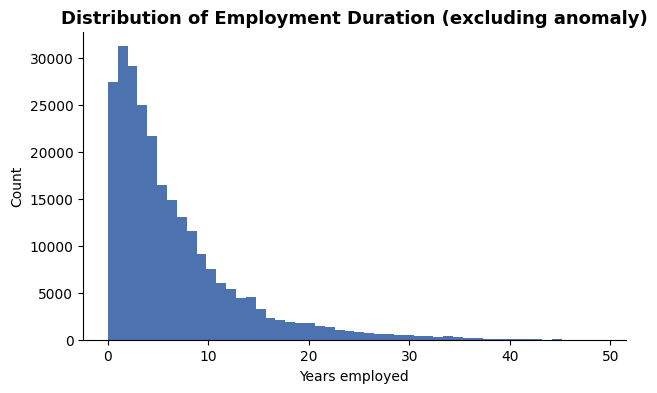

In [13]:
employed = app_train.loc[app_train['DAYS_EMPLOYED'] != 365243, 'DAYS_EMPLOYED']

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(employed / -365, bins=50, color='#4C72B0')
ax.set_xlabel('Years employed')
ax.set_ylabel('Count')
ax.set_title('Distribution of Employment Duration (excluding anomaly)', fontsize=13, weight='bold')
ax.spines[['top', 'right']].set_visible(False)
plt.show()

After removing the anomaly, employment duration is right-skewed as expected —
most applicants have been employed for 0-5 years, tapering off toward 40+
years for a small minority. No further anomalies visible.

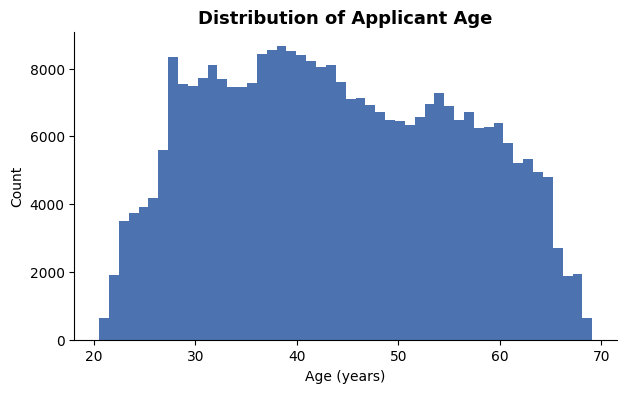

In [14]:
age_years = -app_train['DAYS_BIRTH'] / 365

fig, ax = plt.subplots()
ax.hist(age_years, bins=50, color='#4C72B0')
ax.set_xlabel('Age (years)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Applicant Age')
plt.show()

Applicant age ranges from 20 to 70 years, with the bulk between 30 and 50.
No anomalies here (unlike DAYS_EMPLOYED). Let's check whether age differs
between clients who repaid and those with payment difficulties.

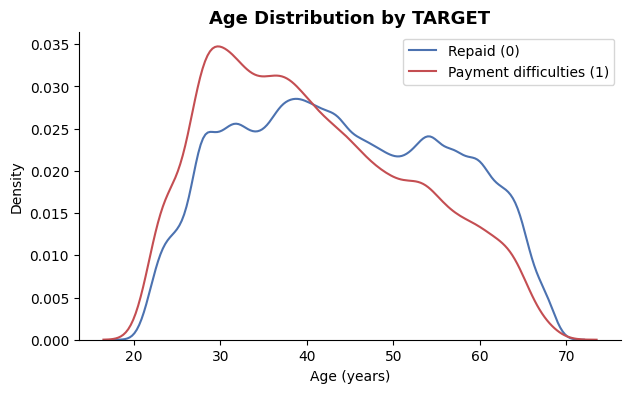

In [15]:
fig, ax = plt.subplots()
sns.kdeplot(age_years[app_train['TARGET'] == 0], label='Repaid (0)', color='#4C72B0', ax=ax)
sns.kdeplot(age_years[app_train['TARGET'] == 1], label='Payment difficulties (1)', color='#C44E52', ax=ax)
ax.set_xlabel('Age (years)')
ax.set_ylabel('Density')
ax.set_title('Age Distribution by TARGET')
ax.legend()
plt.show()

Applicants with payment difficulties (TARGET=1) skew younger — the red curve
peaks around age 30, while repaid loans (TARGET=0) are more evenly spread
into older age groups. This suggests age is a meaningful predictor of
credit risk.

### Income Outliers

AMT_INCOME_TOTAL has a maximum of ~117M, far beyond the 75th percentile of
~202,500. Let's investigate how extreme this outlier situation really is.

In [16]:
print('Applicants with income > 1,000,000:', (app_train['AMT_INCOME_TOTAL'] > 1_000_000).sum())

app_train['AMT_INCOME_TOTAL'].sort_values(ascending=False).head(10)

Applicants with income > 1,000,000: 250


12840     117000000.0
203693     18000090.0
246858     13500000.0
77768       9000000.0
131127      6750000.0
103006      4500000.0
287463      4500000.0
187833      4500000.0
204564      4500000.0
181698      3950059.5
Name: AMT_INCOME_TOTAL, dtype: float64

250 applicants report an income above 1,000,000, but the top value (117M) is
more than 6x higher than the second-highest (18M) — a large jump rather than
a smooth continuation. This looks more like a data entry error (e.g. extra
digits) than a genuine income level. Let's inspect this single row more
closely to sanity-check it against the requested credit amount and other
fields.

In [17]:
app_train.loc[12840, ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 
                       'NAME_INCOME_TYPE', 'OCCUPATION_TYPE', 'TARGET']]

AMT_INCOME_TOTAL    117000000.0
AMT_CREDIT             562491.0
AMT_ANNUITY             26194.5
NAME_INCOME_TYPE        Working
OCCUPATION_TYPE        Laborers
TARGET                        1
Name: 12840, dtype: object

Sanity check confirms our suspicion: this applicant is a "Laborer" (manual
worker) with a modest loan (562,491) and annuity (26,194.5), yet reportedly
earns 117M — and still had payment difficulties (TARGET=1). This combination
is implausible for a genuine income and confirms a data entry error rather
than a real value. We'll cap or otherwise handle extreme income values during
feature engineering, since AMT_INCOME_TOTAL is heavily right-skewed regardless
of this single point.

In [18]:
description[description['Row'].isin(['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY'])]

,Unnamed: 0,Table,Row,Description,Special
7,10,application_{train|test}.csv,AMT_INCOME_TOTAL,Income of the client,NaN
8,11,application_{train|test}.csv,AMT_CREDIT,Credit amount of the loan,NaN
9,12,application_{train|test}.csv,AMT_ANNUITY,Loan annuity,NaN
138,141,bureau.csv,AMT_ANNUITY,Annuity of the Credit Bureau credit,NaN
176,179,previous_application.csv,AMT_ANNUITY,Annuity of previous application,NaN
178,181,previous_application.csv,AMT_CREDIT,Final credit amount on the previous applicatio...,NaN


The reported income and credit amounts seemed unusually high, which raised
the question of currency. Checking HomeCredit_columns_description.csv shows
no currency or time-period information for AMT_INCOME_TOTAL, AMT_CREDIT, or
AMT_ANNUITY. Home Credit B.V. is legally registered in the Netherlands, but
this is just the holding company's domicile — the company was founded in the
Czech Republic and its actual lending operations are concentrated in Eastern
Europe and Asia (e.g. Russia, Vietnam, China, Indonesia), not the Eurozone.
So the currency is genuinely unclear and shouldn't be assumed to be EUR or
USD. This doesn't block modeling, since relative relationships between these
amounts still hold regardless of currency — but it's worth flagging as an
open question rather than guessing.

Since income is heavily right-skewed with a few extreme outliers, a log-scale
view helps visualize the shape of the distribution for the vast majority of
applicants without extreme values compressing everything into one bar.

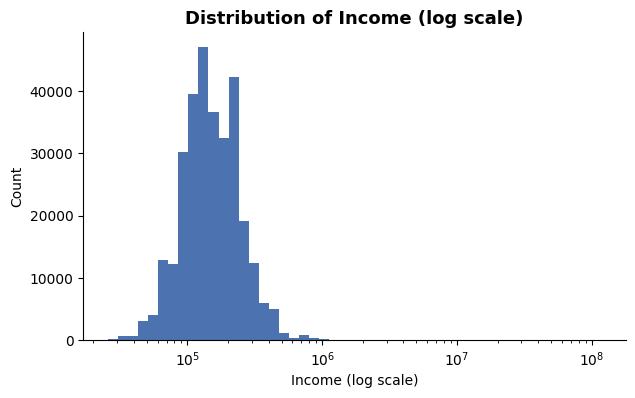

In [19]:
income = app_train['AMT_INCOME_TOTAL']
log_bins = np.logspace(np.log10(income.min()), np.log10(income.max()), 50)

fig, ax = plt.subplots()
ax.hist(income, bins=log_bins, color='#4C72B0')
ax.set_xscale('log')
ax.set_xlabel('Income (log scale)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Income (log scale)')
plt.show()

On a log scale, income is approximately log-normally distributed, with most
applicants between 50,000 and 300,000 and a peak around 150,000-200,000 —
consistent with the median of 147,150 seen earlier. The extreme outliers are
rare enough (250 out of 307,511) to be barely visible here. This log-normal shape adds another point in favor of LightGBM/XGBoost
(mentioned above): tree-based models split on value order rather than
magnitude, so they handle this kind of skew and outliers without requiring
a log transform or scaling — unlike linear/logistic regression.

## Categorical Features

Let's get an overview of all categorical columns and how many distinct
values each contains, before looking at individual features in detail.

In [20]:
categorical_cols = app_train.select_dtypes('object').columns

for col in categorical_cols:
    print(f'{col}: {app_train[col].nunique()} unique values')

NAME_CONTRACT_TYPE: 2 unique values
CODE_GENDER: 3 unique values
FLAG_OWN_CAR: 2 unique values
FLAG_OWN_REALTY: 2 unique values
NAME_TYPE_SUITE: 7 unique values
NAME_INCOME_TYPE: 8 unique values
NAME_EDUCATION_TYPE: 5 unique values
NAME_FAMILY_STATUS: 6 unique values
NAME_HOUSING_TYPE: 6 unique values
OCCUPATION_TYPE: 18 unique values
WEEKDAY_APPR_PROCESS_START: 7 unique values
ORGANIZATION_TYPE: 58 unique values
FONDKAPREMONT_MODE: 4 unique values
HOUSETYPE_MODE: 3 unique values
WALLSMATERIAL_MODE: 7 unique values
EMERGENCYSTATE_MODE: 2 unique values


Most categorical columns have low cardinality (2-8 categories) and can be
visualized directly. Two exceptions stand out: OCCUPATION_TYPE (18) and
ORGANIZATION_TYPE (58), which will need a different approach (e.g. showing
only the top categories). CODE_GENDER also stands out with 3 values instead
of the expected 2 (male/female) — let's check what the third value is.

In [21]:
app_train['CODE_GENDER'].value_counts()

CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

CODE_GENDER contains 'F' (202,448), 'M' (105,059), and 'XNA' (4). The 'XNA'
value is a data placeholder for unspecified/missing entries — consistent with
the same encoding pattern seen earlier in DAYS_EMPLOYED — rather than a
distinct category, given it appears in only 4 out of 307,511 rows. We'll
treat these 4 rows as missing during feature engineering.

Similar to the numerical features earlier, we won't go through all remaining
low-cardinality categorical columns exhaustively. Instead, we start with
NAME_EDUCATION_TYPE, NAME_FAMILY_STATUS, and NAME_HOUSING_TYPE — the ones
most plausibly linked to financial stability and therefore credit risk,
based on domain knowledge (same reasoning as our earlier numerical feature
selection). The two high-cardinality columns (OCCUPATION_TYPE,
ORGANIZATION_TYPE) will need a different approach and come after.

In [22]:
app_train['NAME_EDUCATION_TYPE'].value_counts()

NAME_EDUCATION_TYPE
Secondary / secondary special    218391
Higher education                  74863
Incomplete higher                 10277
Lower secondary                    3816
Academic degree                     164
Name: count, dtype: int64

The vast majority of applicants (71%) have secondary education, followed by
higher education (24%). "Academic degree" is extremely rare (164 out of
307,511, ~0.05%) — any pattern we find for this group later should be
treated with caution due to the small sample size.

Beyond the raw distribution, what matters more for credit risk is whether the
default rate (share of TARGET=1) differs across education levels. Let's
compute and visualize that — this is a pattern we'll repeat for other
categorical features too.

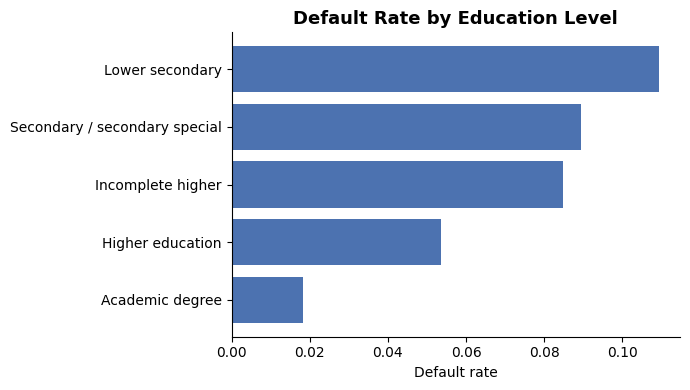

In [23]:
default_rate = app_train.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean().sort_values()

fig, ax = plt.subplots()
ax.barh(default_rate.index, default_rate.values, color='#4C72B0')
ax.set_xlabel('Default rate')
ax.set_title('Default Rate by Education Level')
plt.tight_layout()
plt.show()

Clear pattern: default rate decreases monotonically with education level,
from 11% (Lower secondary) down to 5.3% (Higher education). "Academic
degree" shows the lowest rate (1.8%), but as noted above, this is based on
only 164 applicants, so the estimate is unreliable — a few individual cases
could shift it substantially. Overall, education level looks like a
meaningful predictor of credit risk, in the intuitively expected direction.

In [24]:
app_train['NAME_FAMILY_STATUS'].value_counts()

NAME_FAMILY_STATUS
Married                 196432
Single / not married     45444
Civil marriage           29775
Separated                19770
Widow                    16088
Unknown                      2
Name: count, dtype: int64

Married applicants make up the majority (64%), followed by Single (14.8%),
Civil marriage (9.7%), Separated (6.4%), and Widow (5.2%). "Unknown" appears
only twice out of 307,511 rows — consistent with the same rare-placeholder
pattern seen in CODE_GENDER's "XNA" value, rather than a meaningful category.

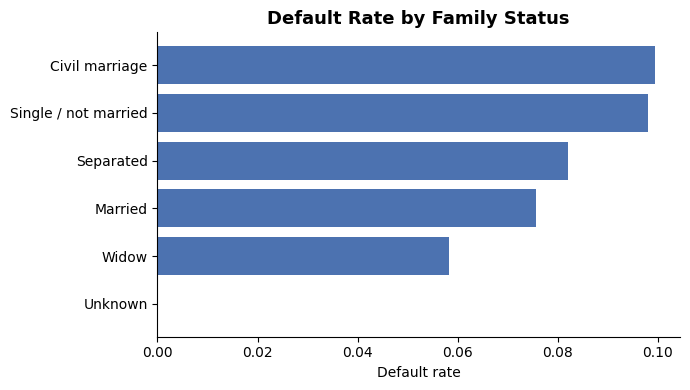

In [25]:
default_rate = app_train.groupby('NAME_FAMILY_STATUS')['TARGET'].mean().sort_values()

fig, ax = plt.subplots()
ax.barh(default_rate.index, default_rate.values, color='#4C72B0')
ax.set_xlabel('Default rate')
ax.set_title('Default Rate by Family Status')
plt.tight_layout()
plt.show()

Civil marriage (9.9%) and Single/not married (9.8%) show the highest default
rates, while Widow has the lowest (5.8%) among the substantial categories.
"Unknown" shows 0% default, but with only 2 applicants this is not a reliable
estimate — same caution as with "Academic degree" earlier. Married applicants
(the largest group) sit roughly in the middle at 7.5%.

In [26]:
app_train['NAME_HOUSING_TYPE'].value_counts()

NAME_HOUSING_TYPE
House / apartment      272868
With parents            14840
Municipal apartment     11183
Rented apartment         4881
Office apartment         2617
Co-op apartment          1122
Name: count, dtype: int64

The vast majority (88.7%) live in their own house/apartment. The remaining
categories are much smaller: With parents (4.8%), Municipal apartment (3.6%),
Rented apartment (1.6%), Office apartment (0.85%), Co-op apartment (0.36%).
Let's check the default rate across these groups.

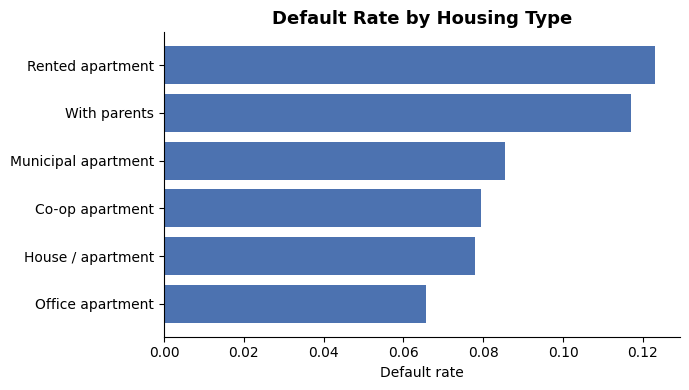

In [27]:
default_rate = app_train.groupby('NAME_HOUSING_TYPE')['TARGET'].mean().sort_values()

fig, ax = plt.subplots()
ax.barh(default_rate.index, default_rate.values, color='#4C72B0')
ax.set_xlabel('Default rate')
ax.set_title('Default Rate by Housing Type')
plt.tight_layout()
plt.show()

Applicants renting or living with parents show the highest default rates
(12.3% and 11.7%), while those with their own house/apartment or an office
apartment show lower rates (7.8% and 6.6%). This is plausible — housing
situation likely reflects financial stability. Note, however, that "With
parents" likely correlates with age (younger applicants are more likely to
live with parents), which we already found to be associated with higher
default rates — so this may partly reflect the same underlying signal rather
than a fully independent effect.

### High-Cardinality Categorical Features

OCCUPATION_TYPE (18 categories) and ORGANIZATION_TYPE (58 categories) need a
different treatment than the previous features — a full bar chart with 58
categories would be unreadable. We'll start with OCCUPATION_TYPE, check for
missing values, then look at the default rate by occupation.

In [28]:
print('Missing:', app_train['OCCUPATION_TYPE'].isnull().sum(), 
      f"({app_train['OCCUPATION_TYPE'].isnull().mean()*100:.1f}%)")

app_train['OCCUPATION_TYPE'].value_counts()

Missing: 96391 (31.3%)


OCCUPATION_TYPE
Laborers                 55186
Sales staff              32102
Core staff               27570
Managers                 21371
Drivers                  18603
High skill tech staff    11380
Accountants               9813
Medicine staff            8537
Security staff            6721
Cooking staff             5946
Cleaning staff            4653
Private service staff     2652
Low-skill Laborers        2093
Waiters/barmen staff      1348
Secretaries               1305
Realty agents              751
HR staff                   563
IT staff                   526
Name: count, dtype: int64

31.3% of OCCUPATION_TYPE values are missing — a substantial share. This could
be connected to the DAYS_EMPLOYED anomaly we found earlier (pensioners/
unemployed applicants without a current job would naturally have no
occupation to report). Let's verify this link.

In [29]:
app_train.loc[app_train['OCCUPATION_TYPE'].isnull(), 'NAME_INCOME_TYPE'].value_counts()

NAME_INCOME_TYPE
Pensioner               55357
Working                 24920
Commercial associate    12297
State servant            3787
Unemployed                 22
Student                     5
Businessman                 2
Maternity leave             1
Name: count, dtype: int64

Our hypothesis is only partially confirmed: Pensioners + Unemployed account
for 57.4% of missing OCCUPATION_TYPE values (55,379 of 96,391), consistent
with "no current job to report." However, the remaining 42.6% are actively
employed applicants (Working, Commercial associate, State servant, etc.) with
missing occupation — likely simply unreported data rather than a logical
consequence of employment status. So the missingness here has at least two
different causes, not one clean explanation.

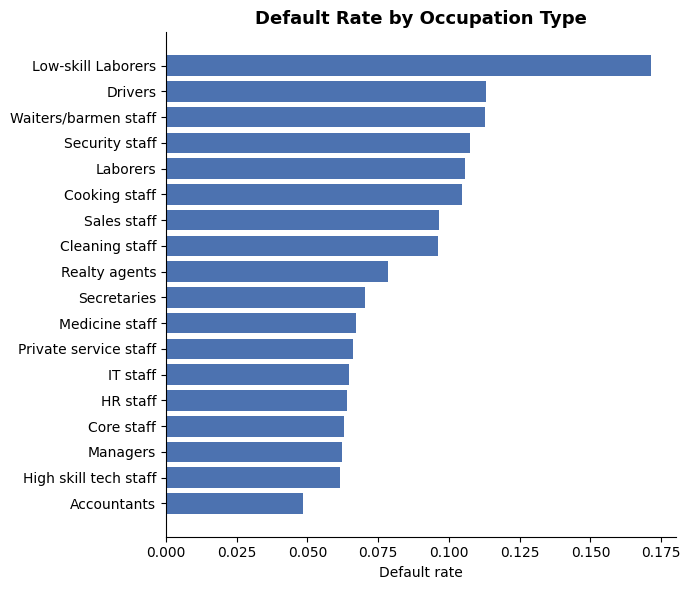

In [30]:
default_rate = app_train.groupby('OCCUPATION_TYPE')['TARGET'].mean().sort_values()

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(default_rate.index, default_rate.values, color='#4C72B0')
ax.set_xlabel('Default rate')
ax.set_title('Default Rate by Occupation Type')
plt.tight_layout()
plt.show()

Clear pattern, consistent with what we found for education and housing:
Low-skill Laborers show by far the highest default rate (17.1%), followed by
Drivers and Waiters/barmen staff (~11.3%). Accountants have the lowest rate
(4.8%), with Managers, High skill tech staff, Core staff, IT and HR staff all
clustered around 6-6.5%. This reinforces a broader theme across the dataset:
lower-skilled/lower-income indicators (education, housing, occupation) are
consistently associated with higher default risk.

With 58 categories, a full bar chart isn't readable. Instead, we'll look at
the default rate for the largest organization types by applicant count (to
avoid unstable estimates from tiny groups).

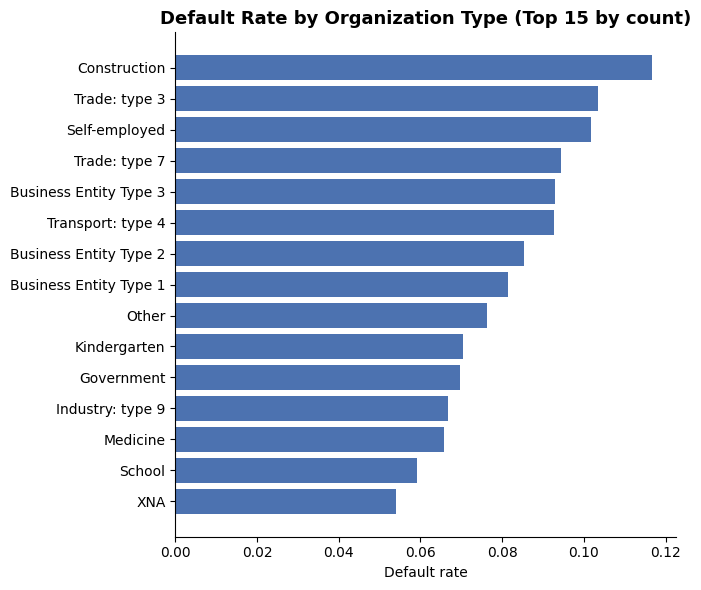

In [31]:
top_orgs = app_train['ORGANIZATION_TYPE'].value_counts().head(15).index

default_rate = (app_train[app_train['ORGANIZATION_TYPE'].isin(top_orgs)]
                 .groupby('ORGANIZATION_TYPE')['TARGET']
                 .mean()
                 .sort_values())

fig, ax = plt.subplots(figsize=(7, 6))
ax.barh(default_rate.index, default_rate.values, color='#4C72B0')
ax.set_xlabel('Default rate')
ax.set_title('Default Rate by Organization Type (Top 15 by count)')
plt.tight_layout()
plt.show()

XNA appears again here, this time as a substantial group (large enough to be
in the top 15 by count) rather than the rare 4-row case in CODE_GENDER. Given
our earlier findings, this is likely applicants without an employer (e.g.
pensioners) rather than a genuine "unknown" category. Let's verify.

In [32]:
app_train.loc[app_train['ORGANIZATION_TYPE'] == 'XNA', 'NAME_INCOME_TYPE'].value_counts()

NAME_INCOME_TYPE
Pensioner     55352
Unemployed       22
Name: count, dtype: int64

Confirmed: 55,352 Pensioners + 22 Unemployed = 55,374 — the exact same count
as the DAYS_EMPLOYED anomaly found earlier. This confirms these three
columns (DAYS_EMPLOYED, OCCUPATION_TYPE, ORGANIZATION_TYPE) consistently
encode the same underlying group of not-currently-employed applicants using
different placeholder values (365243, NaN, XNA respectively) rather than
being independent data issues.

Among applicants with an actual employer, Construction (11.6%), Trade type 3
(10.3%), Self-employed (10.2%), and Trade type 7 (9.4%) show the highest
default rates — plausibly linked to less stable or harder-to-verify income
(seasonal work, self-reported earnings). Government, School, and Medicine
sit at the lower end, consistent with more stable, salaried employment.

In [33]:
description[description['Row'] == 'ORGANIZATION_TYPE']

,Unnamed: 0,Table,Row,Description,Special
40,43,application_{train|test}.csv,ORGANIZATION_TYPE,Type of organization where client works,NaN


Note: the numbered sub-categories (e.g. "Trade type 3" vs. "Trade type 7")
have no documented meaning in the column description — these appear to be
anonymized business classifications, so we can't interpret what specifically
distinguishes them beyond the label itself.

## Correlations with TARGET

So far we've examined individual features based on domain intuition. Now
let's take a systematic approach: compute the correlation of all numerical
features with TARGET, to see which ones show the strongest linear
relationship and whether anything unexpected shows up that we haven't
considered yet.

In [34]:
correlations = app_train.corr(numeric_only=True)['TARGET'].sort_values()

print('Top 10 negative correlations:')
print(correlations.head(10))

print('\nTop 10 positive correlations (excluding TARGET itself):')
print(correlations.drop('TARGET').tail(10).sort_values(ascending=False))

Top 10 negative correlations:
EXT_SOURCE_3                 -0.178919
EXT_SOURCE_2                 -0.160472
EXT_SOURCE_1                 -0.155317
DAYS_EMPLOYED                -0.044932
FLOORSMAX_AVG                -0.044003
FLOORSMAX_MEDI               -0.043768
FLOORSMAX_MODE               -0.043226
AMT_GOODS_PRICE              -0.039645
REGION_POPULATION_RELATIVE   -0.037227
ELEVATORS_AVG                -0.034199
Name: TARGET, dtype: float64

Top 10 positive correlations (excluding TARGET itself):
DAYS_BIRTH                     0.078239
REGION_RATING_CLIENT_W_CITY    0.060893
REGION_RATING_CLIENT           0.058899
DAYS_LAST_PHONE_CHANGE         0.055218
DAYS_ID_PUBLISH                0.051457
REG_CITY_NOT_WORK_CITY         0.050994
FLAG_EMP_PHONE                 0.045982
REG_CITY_NOT_LIVE_CITY         0.044395
FLAG_DOCUMENT_3                0.044346
DAYS_REGISTRATION              0.041975
Name: TARGET, dtype: float64


EXT_SOURCE_1/2/3 stand out clearly, with correlations 3x stronger than any
other feature — worth investigating separately below.

Two things to interpret carefully here:

1. DAYS_BIRTH shows a positive correlation (0.078) with TARGET. Since this
   column is encoded as negative days (more negative = older), a positive
   correlation actually means: as the value increases (i.e. the applicant
   gets younger), TARGET tends to increase too. This confirms our earlier
   finding that younger applicants have higher default rates — the sign
   just looks counterintuitive due to the encoding.

2. DAYS_EMPLOYED's correlation (-0.045) is computed on the raw, uncleaned
   column that still contains the 365243 anomaly (mostly pensioners, a
   lower-risk group). This likely distorts the correlation, so we should
   revisit it after cleaning this feature during feature engineering.

In [35]:
description[description['Row'].str.contains('EXT_SOURCE', na=False)]

,Unnamed: 0,Table,Row,Description,Special
41,44,application_{train|test}.csv,EXT_SOURCE_1,Normalized score from external data source,normalized
42,45,application_{train|test}.csv,EXT_SOURCE_2,Normalized score from external data source,normalized
43,46,application_{train|test}.csv,EXT_SOURCE_3,Normalized score from external data source,normalized


The description only tells us these are "normalized scores from external
data sources" — likely external credit bureau/scoring services, without
revealing which ones exactly (similar anonymization to ORGANIZATION_TYPE).
Given these are by far the strongest predictors we've found, let's check
their missingness and then visualize how they separate TARGET=0 from
TARGET=1.

In [36]:
app_train[['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']].isnull().mean() * 100

EXT_SOURCE_1    56.381073
EXT_SOURCE_2     0.214626
EXT_SOURCE_3    19.825307
dtype: float64

Interesting nuance: EXT_SOURCE_3 has the strongest correlation with TARGET,
but EXT_SOURCE_1 — despite being third-strongest — has by far the most
missing data (56.4%, vs. 19.8% for EXT_SOURCE_3 and just 0.2% for
EXT_SOURCE_2). This matters for feature engineering: EXT_SOURCE_2 is nearly
complete and easy to use directly, while EXT_SOURCE_1 will need a more
careful imputation strategy given how much is missing. Let's visualize how
well these three separate the two TARGET classes.

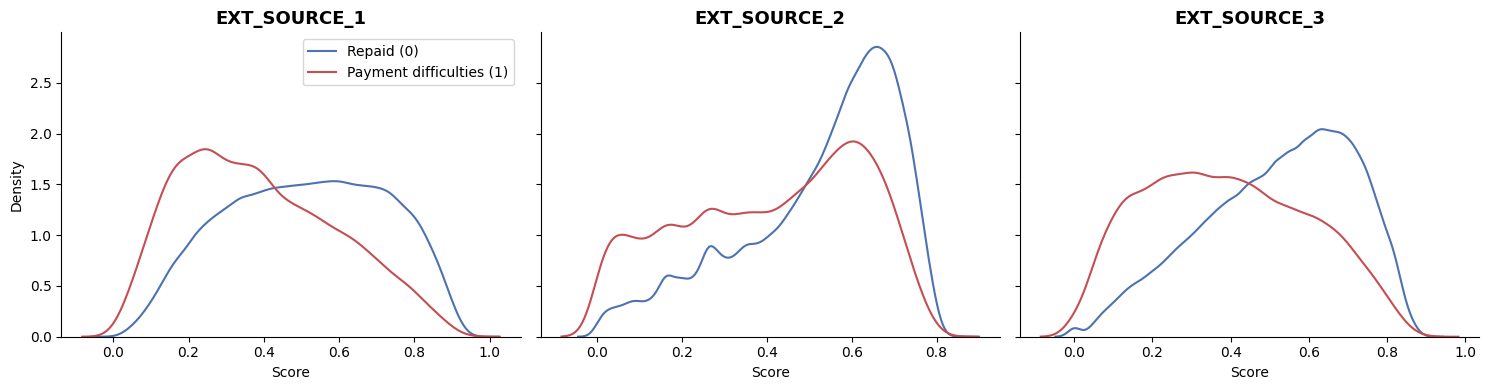

In [37]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for ax, col in zip(axes, ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']):
    sns.kdeplot(app_train.loc[app_train['TARGET'] == 0, col].dropna(), label='Repaid (0)', color='#4C72B0', ax=ax)
    sns.kdeplot(app_train.loc[app_train['TARGET'] == 1, col].dropna(), label='Payment difficulties (1)', color='#C44E52', ax=ax)
    ax.set_title(col)
    ax.set_xlabel('Score')

axes[0].set_ylabel('Density')
axes[0].legend()
plt.tight_layout()
plt.show()

For EXT_SOURCE_1 and EXT_SOURCE_3, the red curve (Payment difficulties) is
visibly shifted toward lower scores compared to blue (Repaid) — a real,
interpretable difference in shape, consistent with lower scores being
associated with higher default risk.

For EXT_SOURCE_2, the shift is much less pronounced and both curves peak in
a similar range, making the relationship harder to read directly from the
KDE shapes alone. Note also that this kind of plot shows the score
distribution *within* each group — it doesn't directly show how default risk
changes as the score changes. A curve rising toward the middle simply
reflects that most applicants (in either group) have mid-range scores, not
that risk increases with score. To confirm the actual relationship cleanly,
especially for EXT_SOURCE_2, we'll compute the default rate by score decile
next.

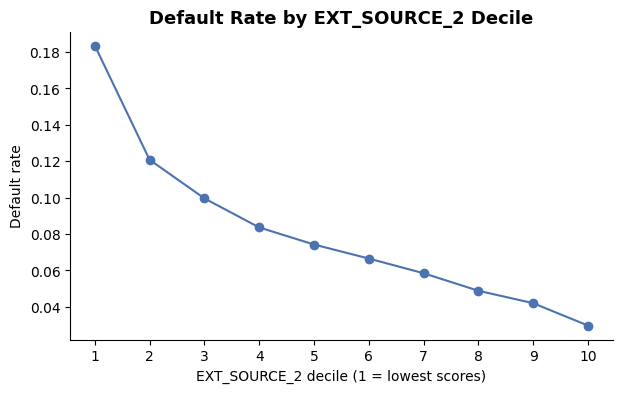

In [38]:
app_train['EXT_SOURCE_2_BIN'] = pd.qcut(app_train['EXT_SOURCE_2'], 10)

default_rate = app_train.groupby('EXT_SOURCE_2_BIN', observed=True)['TARGET'].mean()

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(len(default_rate)), default_rate.values, marker='o', color='#4C72B0')
ax.set_xticks(range(len(default_rate)))
ax.set_xticklabels([f'{i+1}' for i in range(len(default_rate))])
ax.set_xlabel('EXT_SOURCE_2 decile (1 = lowest scores)')
ax.set_ylabel('Default rate')
ax.set_title('Default Rate by EXT_SOURCE_2 Decile')
plt.show()

This resolves the ambiguity cleanly: default rate decreases monotonically
and substantially from 18.3% in the lowest decile to just 3.0% in the
highest — a 6x difference. This confirms EXT_SOURCE_2 (and by extension
EXT_SOURCE_1/3) is a strong, genuine predictor of credit risk, and shows
this relationship much more clearly than the KDE plot or the correlation
coefficient alone.

## Next Steps

- **Feature engineering**: replace the DAYS_EMPLOYED anomaly with NaN + add a boolean flag; handle the AMT_INCOME_TOTAL outlier; encode categorical variables; decide an imputation strategy for EXT_SOURCE_1 (56% missing) and the high-missingness building features.
- **Incorporate the linked tables** (bureau, previous_application, POS_CASH_balance, credit_card_balance, installments_payments, bureau_balance) via aggregation per SK_ID_CURR.
- **Baseline model**: Logistic Regression, to have a reference point.
- **Main model**: LightGBM/XGBoost with class weighting to address the imbalance, evaluated via AUC-ROC.